this notebook loads the EMG data, and plots an average time-frequency plot for each EMG channel in a [-0.5s 0.5s] window around each button press Baseline corrected by the average power in each frequency band during the [-1 0s] window of the EMG data.

In [1]:
# import toolboxes 

import h5py
import mne 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# locate data files

subject_folder = "//rdp.arc.ucl.ac.uk/ritd-ag-project-rd01pz-dbush99/Katja Button Press Data"
button_press_folder = "/beh_data/s05"
EMG_file = "/s05/Subject5_spm_mne-epo.fif"

BP_filepath_1 = subject_folder + button_press_folder + "/behDataMEG.mat"
BP_filepath_2 = subject_folder + button_press_folder + "/targetMEG.mat"
EMG_filepath = subject_folder + EMG_file


In [ ]:
# load button press data

with h5py.File(BP_filepath_1, 'r') as f:
    timings = f['A/timing'][:]
    presses = f['A/press'][:]
timings = timings.T
presses = presses.T

with h5py.File(BP_filepath_2, 'r') as f:
    cuedur = f['T/cueDur'][:]
cuedur = cuedur.T

press_times = (timings + np.tile(cuedur,5)) / 1000

print(f'press times array: {press_times}')
print('\n')
print(f'press times shape: {press_times.shape}')
print('\n')
print(f'press sequence array:{presses}')
print('\n')
print(f'presses array shape {presses.shape}')


In [ ]:
# load all linked split FIF files as one Epochs object
EMG_data = mne.read_epochs(EMG_filepath, preload=True)

In [ ]:
# check the info of the loaded EMG data

print(EMG_data.info)
print(f'Channel Names: {EMG_data.info["ch_names"]}')

In [18]:
# isolate button press channel and EMG channels

BP_channel = EMG_data.get_data(picks='UPPT002')[:,0,:]
EMG_channels = EMG_data.get_data(picks=['EEG057','EEG058','EEG059','EEG060'])
print(f'Button press channel shape: {BP_channel.shape}')
print(f'EMG channels shape: {EMG_channels.shape}')

Button press channel shape: (240, 14801)
EMG channels shape: (240, 4, 14801)


In [19]:
# change UPPT002 channel signal  back by -2.8 seconds to align with button press times. 

BP_channel = np.roll(BP_channel, -int(2.8 * EMG_data.info['sfreq']), axis=1)

C:\Users\marce\AppData\Local\Temp\ipykernel_30604\2584622589.py:22: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(['Channel signal'],['Button Press'])


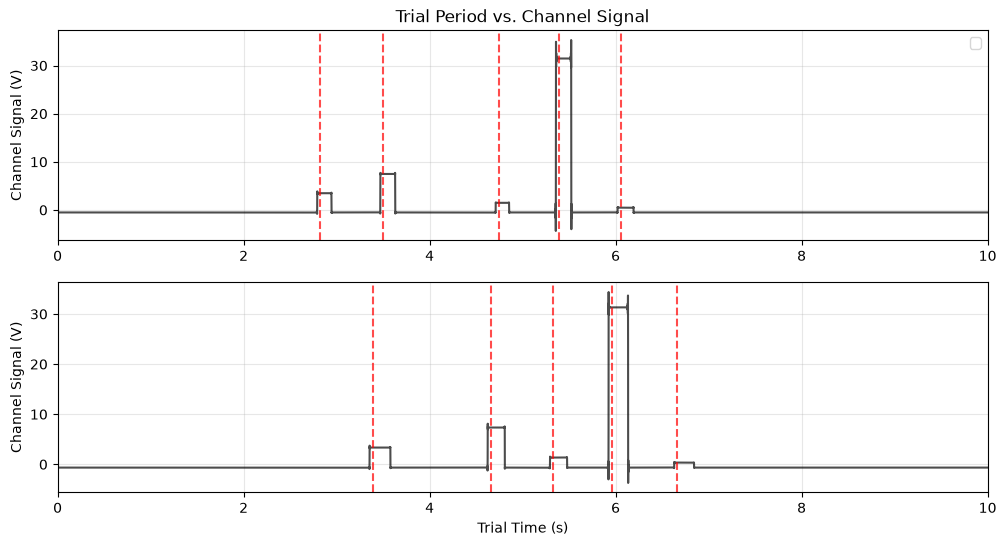

In [40]:
# checking if the list of press times for each trial match the signal in UPPT002 channel

plt.figure(figsize=(12, 6))
plt.title('Trial Period vs. Channel Signal')
plt.axis('off')

plt.subplot(2,1,1)
plt.plot(EMG_data.times, BP_channel[152],
         color='black',
         alpha=0.7,
        )

for idx,pt in enumerate(press_times[152]):
    plt.axvline(
        x=pt,
        color='r',
        linestyle='--',
        alpha=0.7,
        )
plt.ylabel('Channel Signal (V)')
plt.xlim([0, 10])
plt.legend(['Channel signal'],['Button Press'])
plt.grid(alpha=0.3,which='both',axis='both')

plt.subplot(2,1,2)
plt.plot(EMG_data.times, BP_channel[1],
         color='black',
         alpha=0.7,
        )

for idx,pt in enumerate(press_times[1]):
    plt.axvline(
        x=pt,
        color='r',
        linestyle='--',
        alpha=0.7,
        )
plt.xlabel('Trial Time (s)')
plt.ylabel('Channel Signal (V)')
plt.xlim([0, 10])
plt.grid(alpha=0.3,which='both',axis='both')
    
plt.show()

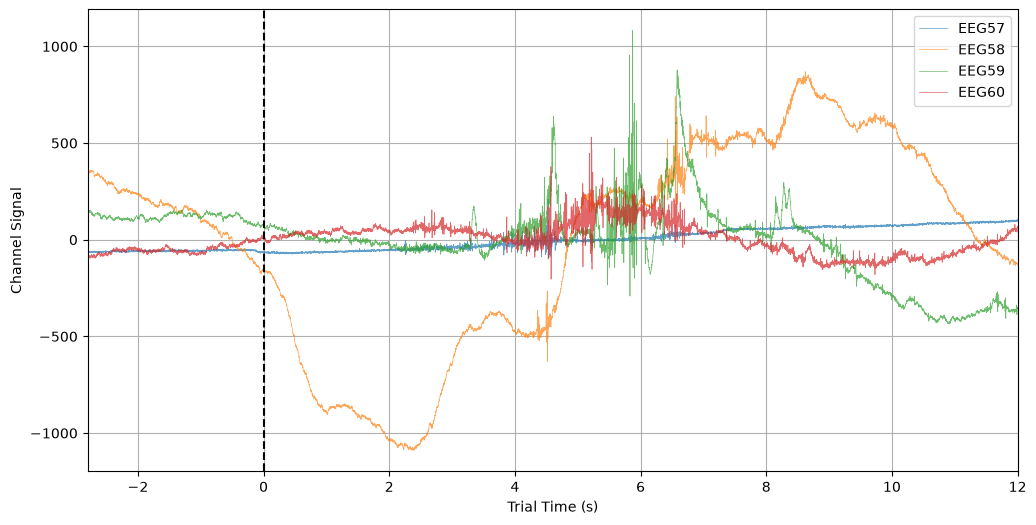

In [43]:
# check EEG channels for each trial
plt.figure(figsize=(12, 6))

for idx in range(4):
    plt.plot(EMG_data.times-2.8, EMG_channels[0,idx,:],
              alpha=0.7,
              label=f"EEG{57+idx}",
              linewidth=0.5
    )
plt.axvline(x=0,
            color='black',
            linestyle = '--'
            )
plt.xlim(EMG_data.times[0] - 2.8, EMG_data.times[-1] - 2.8)
plt.xlabel('Trial Time (s)')
plt.ylabel('Channel Signal')
plt.legend()
plt.grid()
plt.show()
